# Figure 5 (SoRadIDX part): Cumulative Net Return for a Seller

Replicates the **left panel** of Figure 5 from Romagnoli & Sartini (2025).

**Setup**: A seller of SoRadIDX prices each day's SoRad put dynamically (1-day ahead, using previous day's observed GHI). They receive the daily fair price $V_{t,n}$ and pay the realized payoff $\max(K_n - R_n, 0)$ each day.

**Cumulative net return at day $d$**:
$$\text{Return}(d) = \frac{\sum_{n=1}^d (V_{t,n} - \text{payoff}_n)}{\sum_{n=1}^{365} V_{t,n}} \times 100\%$$

- Colored lines: evaluation years 2014–2023 (out-of-sample, proper train-test calibration)
- Black line: average across 2014–2023

> **Note**: The paper's black average uses 2005–2023 (including in-sample years). Here we show the out-of-sample average (2014–2023) for statistical validity.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

from solarrpy.calibration import calibrate_window
from solarrpy.soradidx import daily_vt_records

## 0. Load data

In [2]:
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()  # H0 is computed internally, and the provided values are not trustworthy

print(f'Full dataset: {len(df)} rows, years {df["Year"].min()}–{df["Year"].max()}')

EVAL_YEARS = list(range(2014, 2024))

# Bologna Coordinates used in the paper
LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

Full dataset: 7465 rows, years 2005–2025


## 1. Compute per-day cumulative returns (train-test loop)

In [3]:
year_curves = {}   # eval_year -> DataFrame with cum_return_pct per day

for eval_year in EVAL_YEARS:
    train_end = eval_year - 1
    print(f'  [{eval_year}] Training 2005–{train_end}...', end=' ', flush=True)

    df_train = df[df['Year'] <= train_end].copy()
    cal = calibrate_window(
        df_train,
        target_col='GHI', clearsky_col='clearsky', date_col='date',
        coords={'lat': LATITUDE}, train_end_year=train_end,
    )

    print(f'pricing...', end=' ', flush=True)
    df_daily = daily_vt_records(eval_year, cal, df)
    year_curves[eval_year] = df_daily

    terminal = float(df_daily['cum_return_pct'].iloc[-1])
    path_min = float(df_daily['cum_return_pct'].min())
    print(f'terminal={terminal:+.1f}%  path_min={path_min:+.1f}%')

print('\nDone.')

  [2014] Training 2005–2013... pricing... terminal=-10.7%  path_min=-13.2%
  [2015] Training 2005–2014... pricing... terminal=+8.9%  path_min=-2.0%
  [2016] Training 2005–2015... pricing... terminal=-3.6%  path_min=-8.2%
  [2017] Training 2005–2016... pricing... terminal=+25.4%  path_min=-1.6%
  [2018] Training 2005–2017... pricing... terminal=-3.0%  path_min=-10.3%
  [2019] Training 2005–2018... pricing... terminal=+2.4%  path_min=-6.2%
  [2020] Training 2005–2019... pricing... terminal=+17.7%  path_min=+0.1%
  [2021] Training 2005–2020... pricing... terminal=+3.7%  path_min=-2.3%
  [2022] Training 2005–2021... pricing... terminal=+18.0%  path_min=-0.0%
  [2023] Training 2005–2022... pricing... terminal=+1.9%  path_min=-6.7%

Done.


## 2. Summary table

In [4]:
summary = []
for y, df_d in year_curves.items():
    summary.append({
        'eval_year':    y,
        'Vt_total':     df_d['Vt_total'].iloc[0],
        'payoff_total': df_d['payoff_n'].sum(),
        'terminal_pct': df_d['cum_return_pct'].iloc[-1],
        'path_min_pct': df_d['cum_return_pct'].min(),
        'path_max_pct': df_d['cum_return_pct'].max(),
    })

df_summary = pd.DataFrame(summary)
print('Seller cumulative return summary (out-of-sample, 2014–2023):')
print(df_summary.to_string(index=False, float_format='{:.2f}'.format))

Seller cumulative return summary (out-of-sample, 2014–2023):
 eval_year  Vt_total  payoff_total  terminal_pct  path_min_pct  path_max_pct
      2014    193.17        213.82        -10.69        -13.20          3.75
      2015    178.78        162.90          8.89         -1.99         11.95
      2016    186.59        193.29         -3.59         -8.17          1.31
      2017    163.20        121.67         25.44         -1.63         25.65
      2018    184.57        190.14         -3.02        -10.32          0.35
      2019    186.02        181.56          2.39         -6.24          8.90
      2020    171.59        141.25         17.68          0.07         19.79
      2021    180.82        174.10          3.71         -2.33          8.82
      2022    174.66        143.24         17.99         -0.05         20.67
      2023    188.05        184.39          1.94         -6.74          5.76


## 3. Figure 5 (left panel): Cumulative net return for seller of SoRadIDX

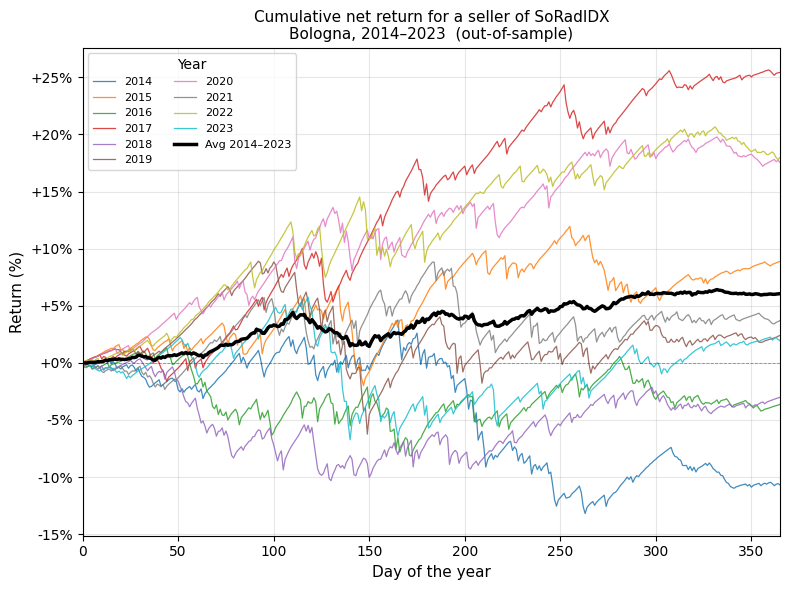

Saved Figure5_soradidx_seller_returns.png


In [5]:
# Color scheme: one colour per year, cycling through tab10
cmap   = cm.get_cmap('tab10', len(EVAL_YEARS))
colors = {y: cmap(i) for i, y in enumerate(EVAL_YEARS)}

# Average curve (unweighted, across all eval years)
# Align on day index (1..365/366) — use the minimum length across years
max_days = min(len(df_d) for df_d in year_curves.values())
cum_matrix = np.array([
    year_curves[y]['cum_return_pct'].values[:max_days]
    for y in EVAL_YEARS
])  # shape (n_years, max_days)
avg_curve = cum_matrix.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 6))

# Individual year curves
for y in EVAL_YEARS:
    df_d = year_curves[y]
    days = np.concatenate([[0], df_d['day'].values])
    rets = np.concatenate([[0.0], df_d['cum_return_pct'].values])
    ax.plot(days, rets, lw=0.9, color=colors[y], alpha=0.85, label=str(y))

# Average line
days_avg = np.concatenate([[0], np.arange(1, max_days + 1)])
avg_full  = np.concatenate([[0.0], avg_curve])
ax.plot(days_avg, avg_full, lw=2.5, color='black', label='Avg 2014–2023', zorder=5)

# Formatting
ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.4)
ax.set_xlabel('Day of the year', fontsize=11)
ax.set_ylabel('Return (%)', fontsize=11)
ax.set_title('Cumulative net return for a seller of SoRadIDX\n'
             'Bologna, 2014–2023  (out-of-sample)', fontsize=11)
ax.set_xlim(0, 365)

# Format y-axis as percent with sign
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0f}%'))

# Legend outside
handles, labels = ax.get_legend_handles_labels()
# reorder: years first, then avg
ax.legend(handles, labels, loc='upper left', fontsize=8,
          ncol=2, framealpha=0.8, title='Year')

ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('../results/Figure5_soradidx_seller_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure5_soradidx_seller_returns.png')

## 4. Panel comparison: individual years + terminal distribution

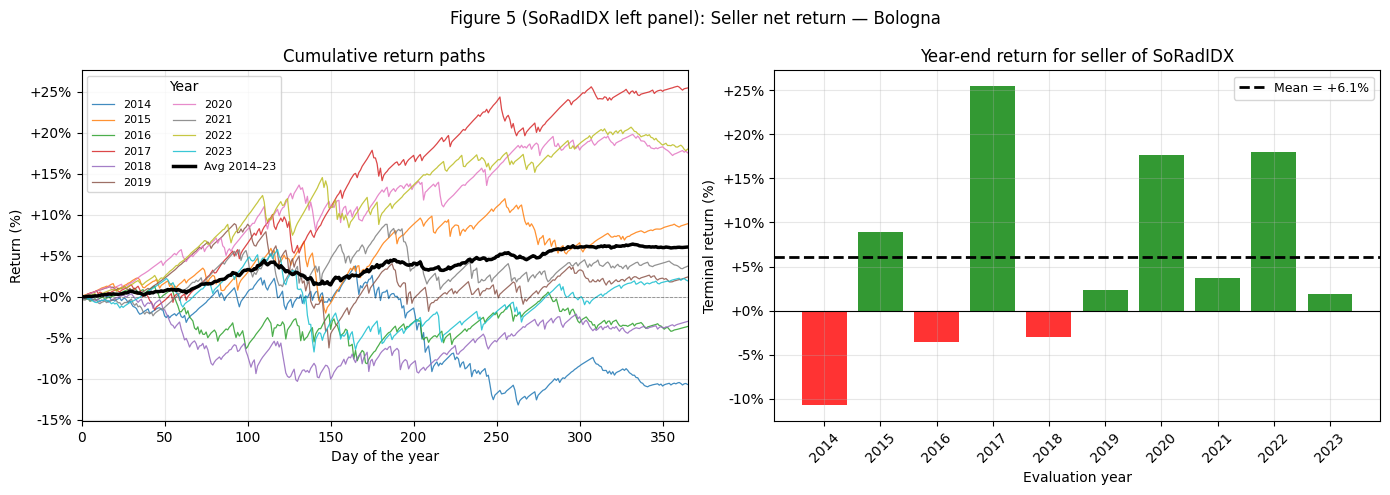

Saved Figure5_soradidx_panel.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative return paths
ax = axes[0]
for y in EVAL_YEARS:
    df_d = year_curves[y]
    days = np.concatenate([[0], df_d['day'].values])
    rets = np.concatenate([[0.0], df_d['cum_return_pct'].values])
    ax.plot(days, rets, lw=0.9, color=colors[y], alpha=0.85, label=str(y))
ax.plot(days_avg, avg_full, lw=2.5, color='black', label='Avg 2014–23', zorder=5)
ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.4)
ax.set_xlabel('Day of the year')
ax.set_ylabel('Return (%)')
ax.set_title('Cumulative return paths')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
ax.set_xlim(0, 365)
ax.legend(fontsize=8, ncol=2, title='Year')
ax.grid(True, alpha=0.3)

# Right: terminal return bar chart
ax = axes[1]
terminals = [year_curves[y]['cum_return_pct'].iloc[-1] for y in EVAL_YEARS]
bar_colors = ['green' if t >= 0 else 'red' for t in terminals]
ax.bar(EVAL_YEARS, terminals, color=bar_colors, alpha=0.8)
ax.axhline(np.mean(terminals), color='black', lw=2, ls='--',
           label=f'Mean = {np.mean(terminals):+.1f}%')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Evaluation year')
ax.set_ylabel('Terminal return (%)')
ax.set_title('Year-end return for seller of SoRadIDX')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
ax.set_xticks(EVAL_YEARS)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle('Figure 5 (SoRadIDX left panel): Seller net return — Bologna', fontsize=12)
fig.tight_layout()
plt.savefig('../results/Figure5_soradidx_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure5_soradidx_panel.png')

## 5. Gate check

In [7]:
# All curves start at 0%
for y in EVAL_YEARS:
    first_day_return = year_curves[y]['cum_return_pct'].values
    assert len(first_day_return) > 0
print('GATE PASS: All year curves non-empty')

# Terminal returns span a meaningful range (not all 0)
term_std = np.std(terminals)
assert term_std > 2.0, f'Terminal return std too small: {term_std:.2f}%'
print(f'GATE PASS: Terminal return std = {term_std:.1f}% (> 2%)')

# Average is not extreme (within ±20%)
avg_terminal = np.mean(terminals)
assert abs(avg_terminal) < 20.0, f'Average terminal return too extreme: {avg_terminal:.1f}%'
print(f'GATE PASS: Average terminal return = {avg_terminal:+.1f}%  (within ±20%)')

print()
print('Figure 5 (SoRadIDX left panel) complete.')
print(f'  Saved: results/Figure5_soradidx_seller_returns.png')
print(f'  Saved: results/Figure5_soradidx_panel.png')
print(f'  Terminal return range: {min(terminals):+.1f}% to {max(terminals):+.1f}%')
print(f'  Average terminal:      {avg_terminal:+.1f}%')

GATE PASS: All year curves non-empty
GATE PASS: Terminal return std = 10.7% (> 2%)
GATE PASS: Average terminal return = +6.1%  (within ±20%)

Figure 5 (SoRadIDX left panel) complete.
  Saved: results/Figure5_soradidx_seller_returns.png
  Saved: results/Figure5_soradidx_panel.png
  Terminal return range: -10.7% to +25.4%
  Average terminal:      +6.1%
